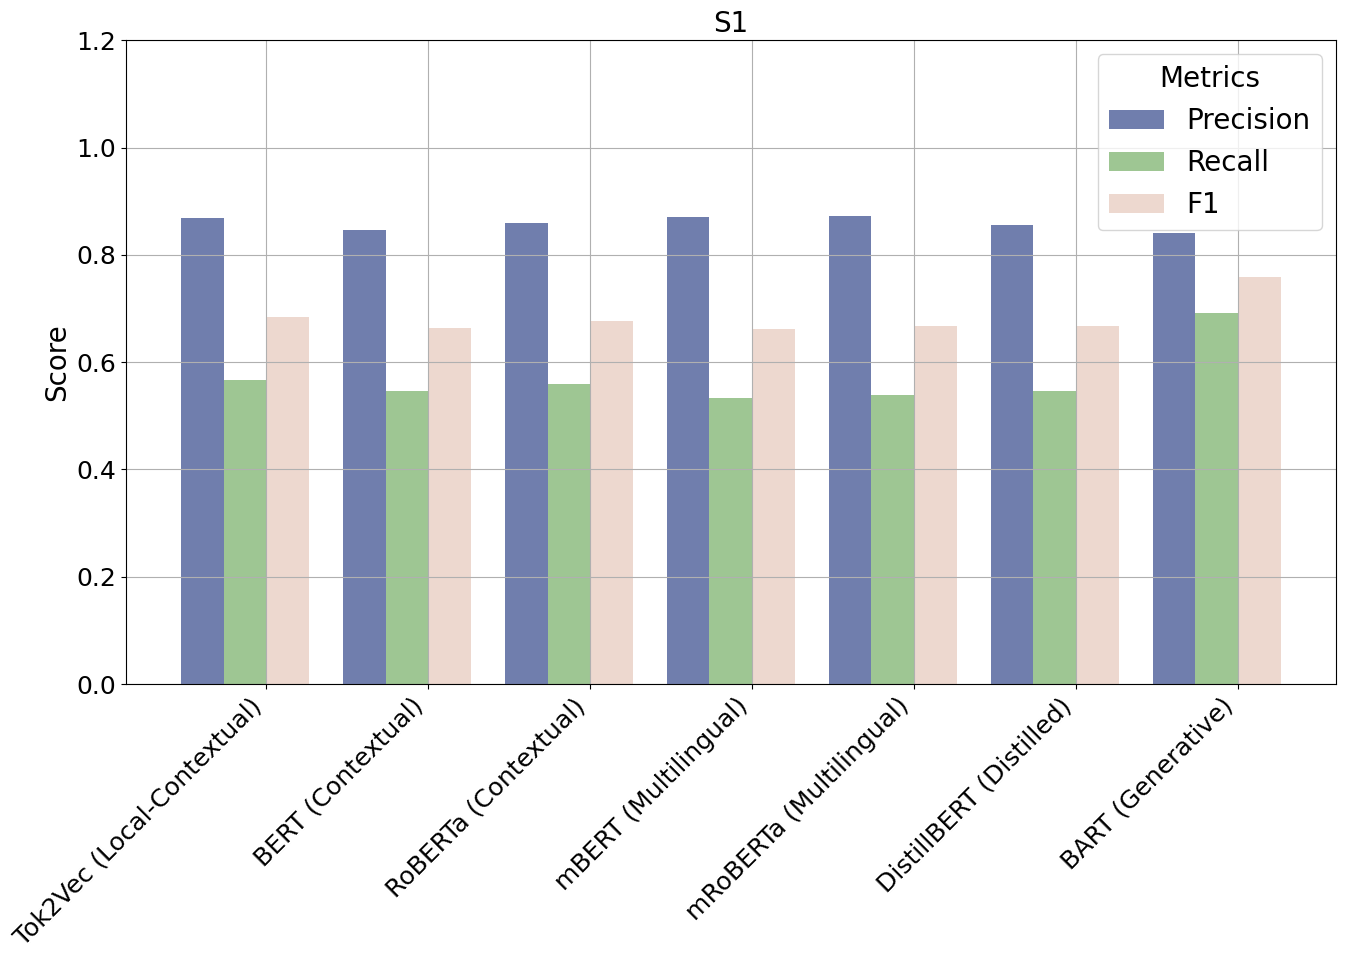

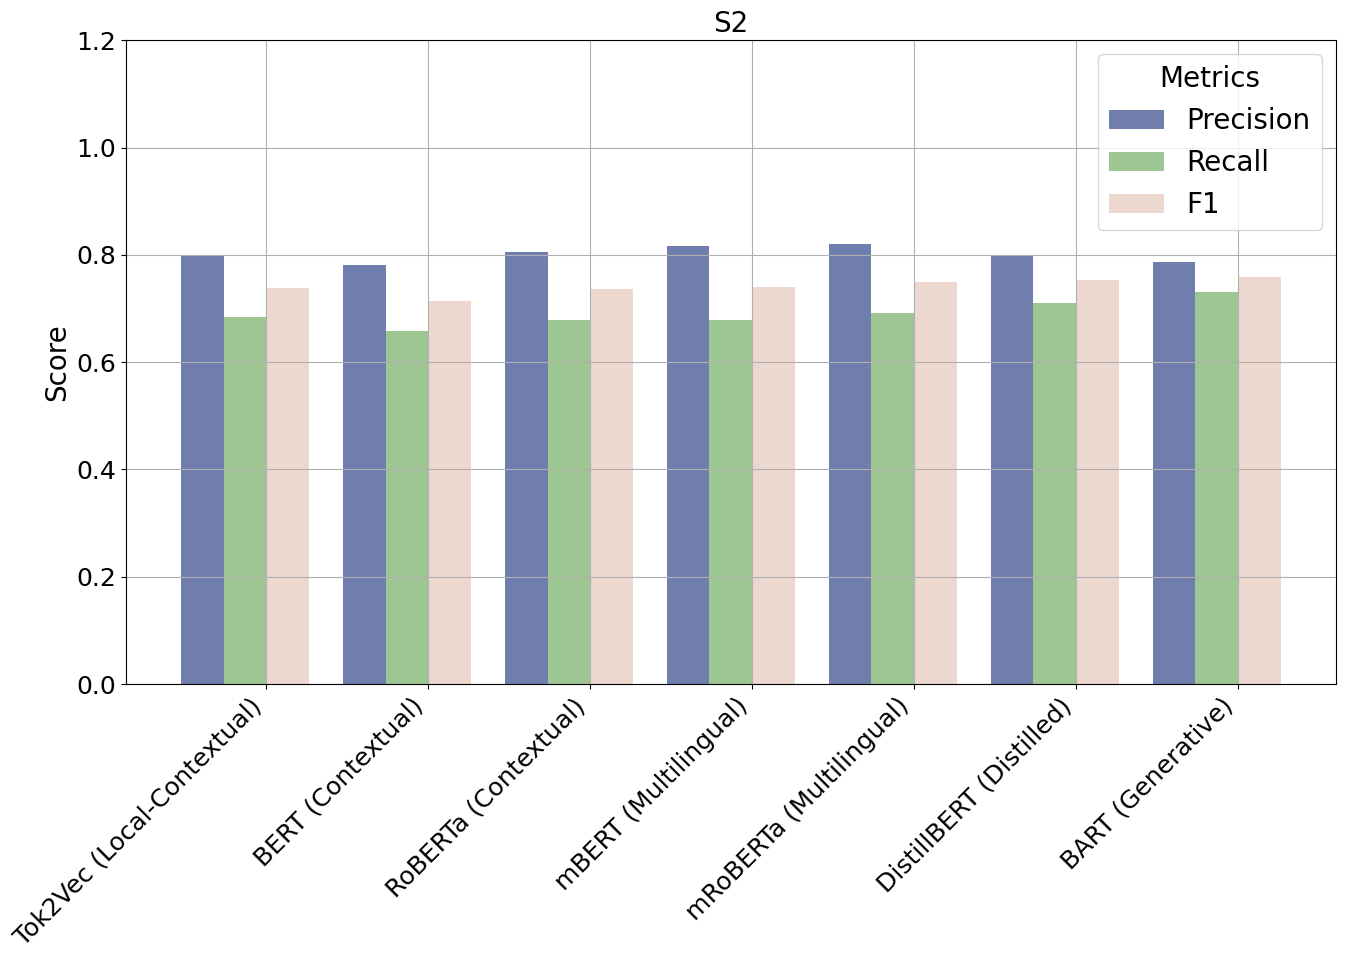

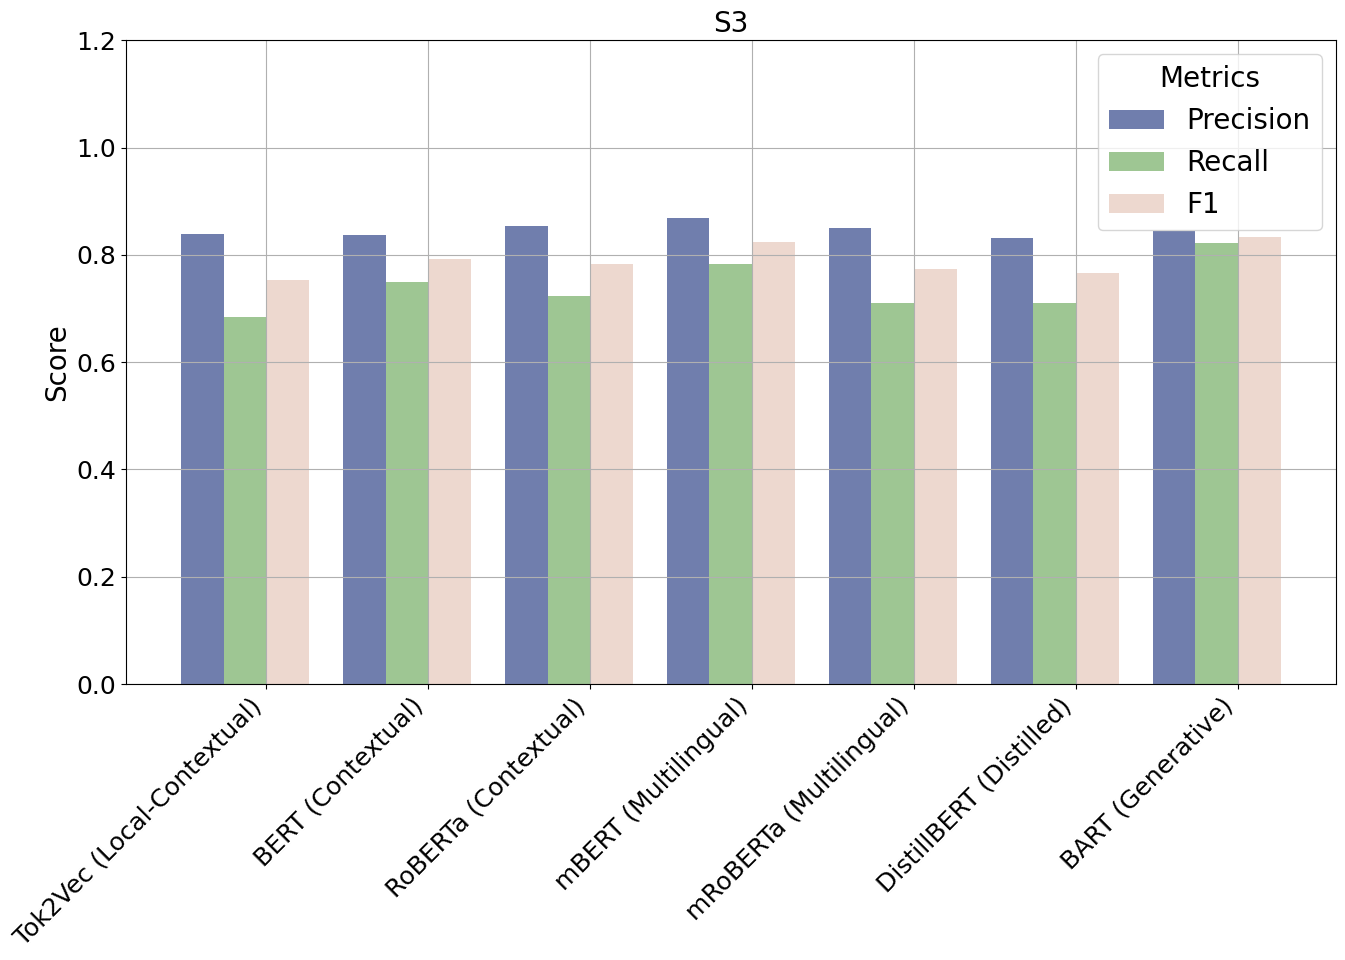

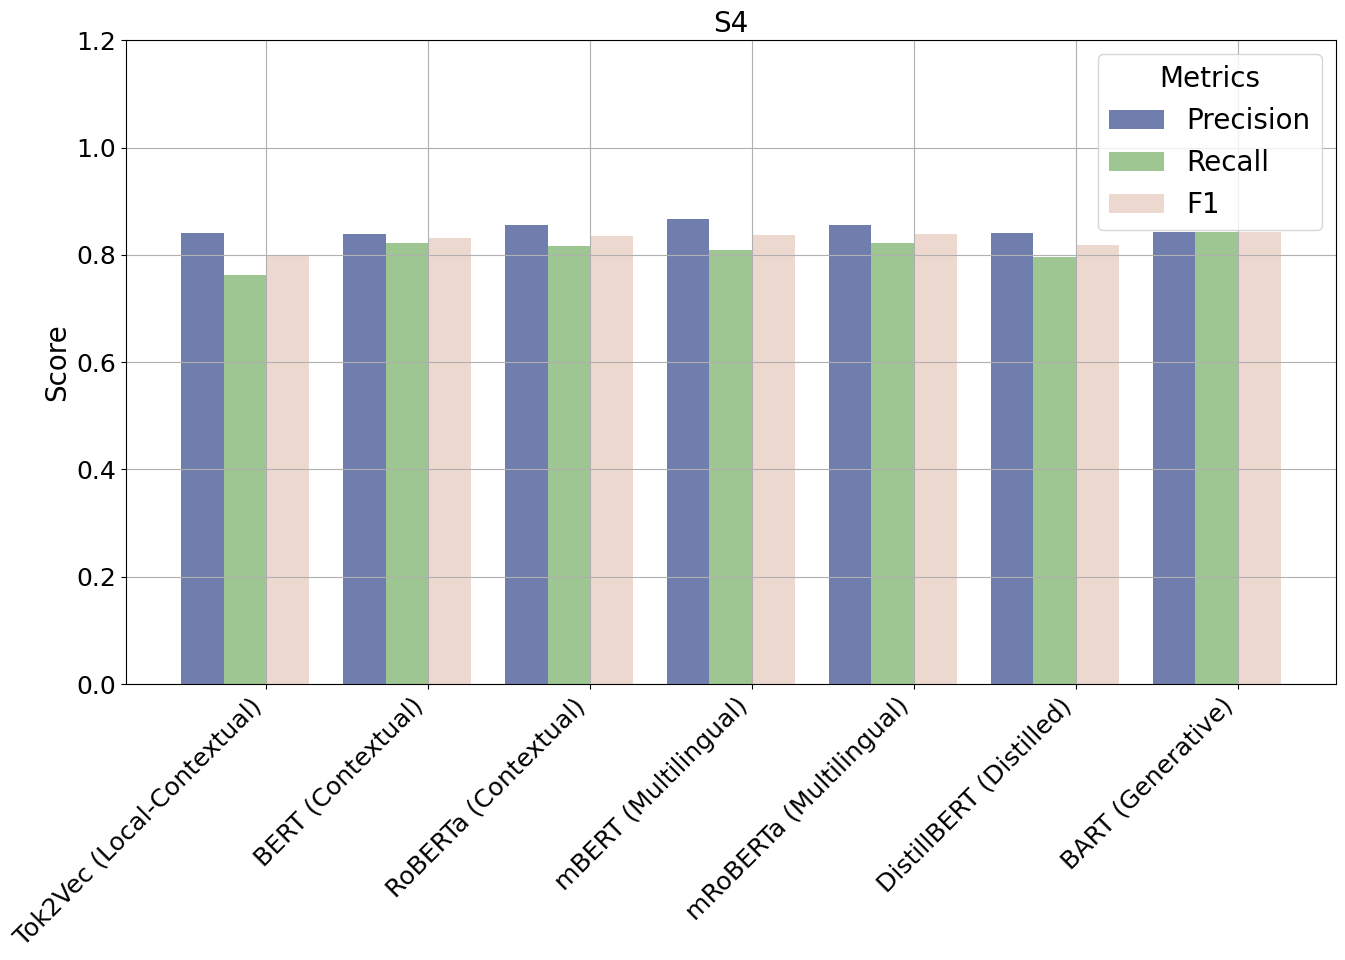

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 7 models (the groups on the x-axis)
models = [
    'Tok2Vec (Local-Contextual)', 
    'BERT (Contextual)', 
    'RoBERTa (Contextual)', 
    'mBERT (Multilingual)',
    'mRoBERTa (Multilingual)',
    'DistillBERT (Distilled)',
    'BART (Generative)'
]

# Data for each of the four setups: 
# Each entry is [Precision, Recall, F1] in the order of the 7 models.
# 1) Training w/o ATC rules, No Override
setup1 = [
    [0.869, 0.566, 0.685],  
    [0.847, 0.546, 0.664],  
    [0.859, 0.559, 0.677],  
    [0.871, 0.533, 0.661],  
    [0.872, 0.539, 0.667],  
    [0.856, 0.546, 0.667],  
    [0.840, 0.691, 0.758]   
]

# 2) Training w/o ATC rules, Override w/ ATC rules
setup2 = [
    [0.800, 0.684, 0.738],  
    [0.781, 0.658, 0.714],  
    [0.805, 0.678, 0.736],  
    [0.817, 0.678, 0.741],  
    [0.820, 0.691, 0.750],  
    [0.800, 0.711, 0.753],  
    [0.787, 0.730, 0.758]   
]

# 3) Training w/ ATC rules, No Override
setup3 = [
    [0.839, 0.684, 0.754],  
    [0.838, 0.750, 0.792],  
    [0.853, 0.724, 0.783],  
    [0.869, 0.783, 0.824],  
    [0.850, 0.711, 0.774],  
    [0.831, 0.711, 0.766],  
    [0.845, 0.822, 0.833]   
]

# 4) Training w/ ATC rules, Override w/ ATC rules
setup4 = [
    [0.841, 0.763, 0.800],  
    [0.839, 0.822, 0.831],  
    [0.855, 0.816, 0.835],  
    [0.866, 0.809, 0.837],  
    [0.856, 0.822, 0.839],  
    [0.840, 0.796, 0.818],  
    [0.842, 0.842, 0.842]   
]


def plot_setup(data, title, figure_name, models):
    """
    Plots a grouped bar chart for one scenario (Precision, Recall, F1)
    for each of the 7 models. All 'Precision' bars share one color,
    all 'Recall' bars share another, all 'F1' bars share a third.
    """
    n_models = len(models)    # 7
    x_indices = np.arange(n_models)  # 0,1,2,...,6
    
    # We have 3 metrics in each group
    n_metrics = 3  
    bar_width = 0.25  # width of each bar
    group_gap = 0.2   # gap between groups (optional for clarity)
    group_width = n_metrics * bar_width  # total width of P/R/F1 bars in one group
    step = group_width + group_gap       # distance to next group on x-axis
    
    # Discrete colors from 'winter' colormap
    cmap = plt.get_cmap('gist_earth')
    # We'll pick 3 spaced values along the colormap. 
    # For example: 0.2, 0.5, 0.8.
    p_color = cmap(0.1)
    r_color = cmap(0.5)
    f_color = cmap(0.9)
    
    # Prepare figure
    fig, ax = plt.subplots(figsize=(14, 10))
    plt.rcParams.update({
        'font.size': 20,
        'axes.titlesize': 20,
        'axes.labelsize': 20,
        'xtick.labelsize': 18,
        'ytick.labelsize': 18,
        'legend.fontsize': 20
    })
    # For each metric (Precision, Recall, F1), draw bars across all models
    #   - data[i][0] = precision for model i
    #   - data[i][1] = recall for model i
    #   - data[i][2] = f1 for model i
    # so we'll slice accordingly for each metric index j
    # Position each group at i*step, and offset by j*bar_width for the j-th metric
    for j, (metric_name, color) in enumerate(zip(
        ["Precision", "Recall", "F1"],
        [p_color, r_color, f_color]
    )):
        # x positions for the j-th metric across the 7 groups
        x_positions = [i*step + j*bar_width for i in range(n_models)]
        # y values for this metric across the 7 models
        y_values = [row[j] for row in data]

        ax.bar(
            x_positions,
            y_values,
            width=bar_width,
            color=color,
            edgecolor='none',
            alpha=0.6,
            label=metric_name 
            # We'll set the label only for j=0, j=1, j=2 
            # because the legend merges them anyway 
        )
    
    # Create the tick marks in the middle of each group
    # The center of group i is i*step + group_width/2
    group_centers = [i*step + group_width/2 for i in range(n_models)]

    ax.set_xticks(group_centers)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylim([0, 1.2])
    ax.set_ylabel("Score")
    ax.set_title(title)

    # Build a legend with the three metric colors
    ax.legend(loc='best', title="Metrics")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{figure_name}.png', dpi=300)
    plt.show()


# Now generate each figure, one by one:
plot_setup(setup1, "S1", "scores_setup1", models)
plot_setup(setup2, "S2", "scores_setup2", models)
plot_setup(setup3, "S3", "scores_setup3", models)
plot_setup(setup4, "S4", "scores_setup4", models)


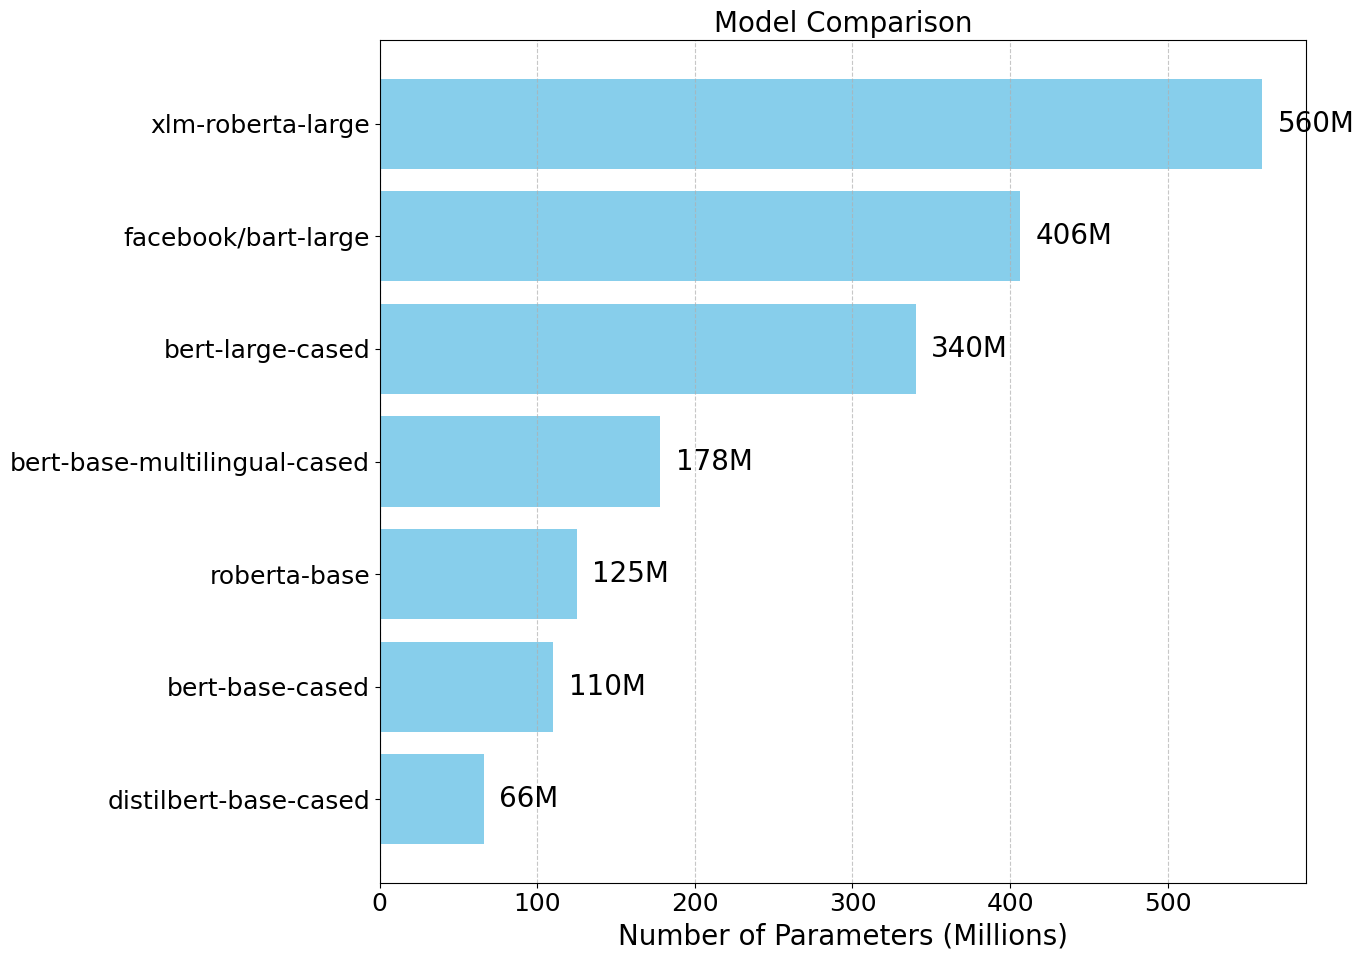

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

models = {
    "xlm-roberta-large": 560,
    "facebook/bart-large": 406,
    "bert-large-cased": 340,
    "bert-base-multilingual-cased": 178,
    "roberta-base": 125,
    "bert-base-cased": 110,
    "distilbert-base-cased": 66
}

df = pd.DataFrame(models.items(), columns=['Model', 'Parameters (Millions)'])
df = df.sort_values(by='Parameters (Millions)', ascending=True)

plt.figure(figsize=(14, 10))
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20
})

bars = plt.barh(df['Model'], df['Parameters (Millions)'], color='skyblue')
plt.title('Model Comparison')
plt.xlabel('Number of Parameters (Millions)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2, 
             f'{width}M', va='center')

plt.tight_layout()
plt.savefig("n_parameters.png", dpi=300)
plt.show()

In [28]:
# the value in the array are for 
time_data = {
        "Tok2Vec": [0.03,0.03,0.02,0.02],
        "DistillBERT": [0.64, 0.65, 0.59, 0.61],
        "BERT": [1.52, 1.61, 1.44, 1.52],
        "RoBERTa": [1.07, 1.42, 1.07, 1.43], 
        "mBERT": [1.42, 1.47, 1.42, 1.49],
        "mRoBERTa": [3.37, 3.36, 3.70, 4.02],
        "BART": [3.42, 3.72, 4.03, 4.03], 
        }

space = {
        "Tok2Vec": [],
        "BERT": [],
        "RoBERTa": [], 
        "mBERT": [],
        "mRoBERTa": [],
        "DistillBERT": [],
        "BART": [], 
        }

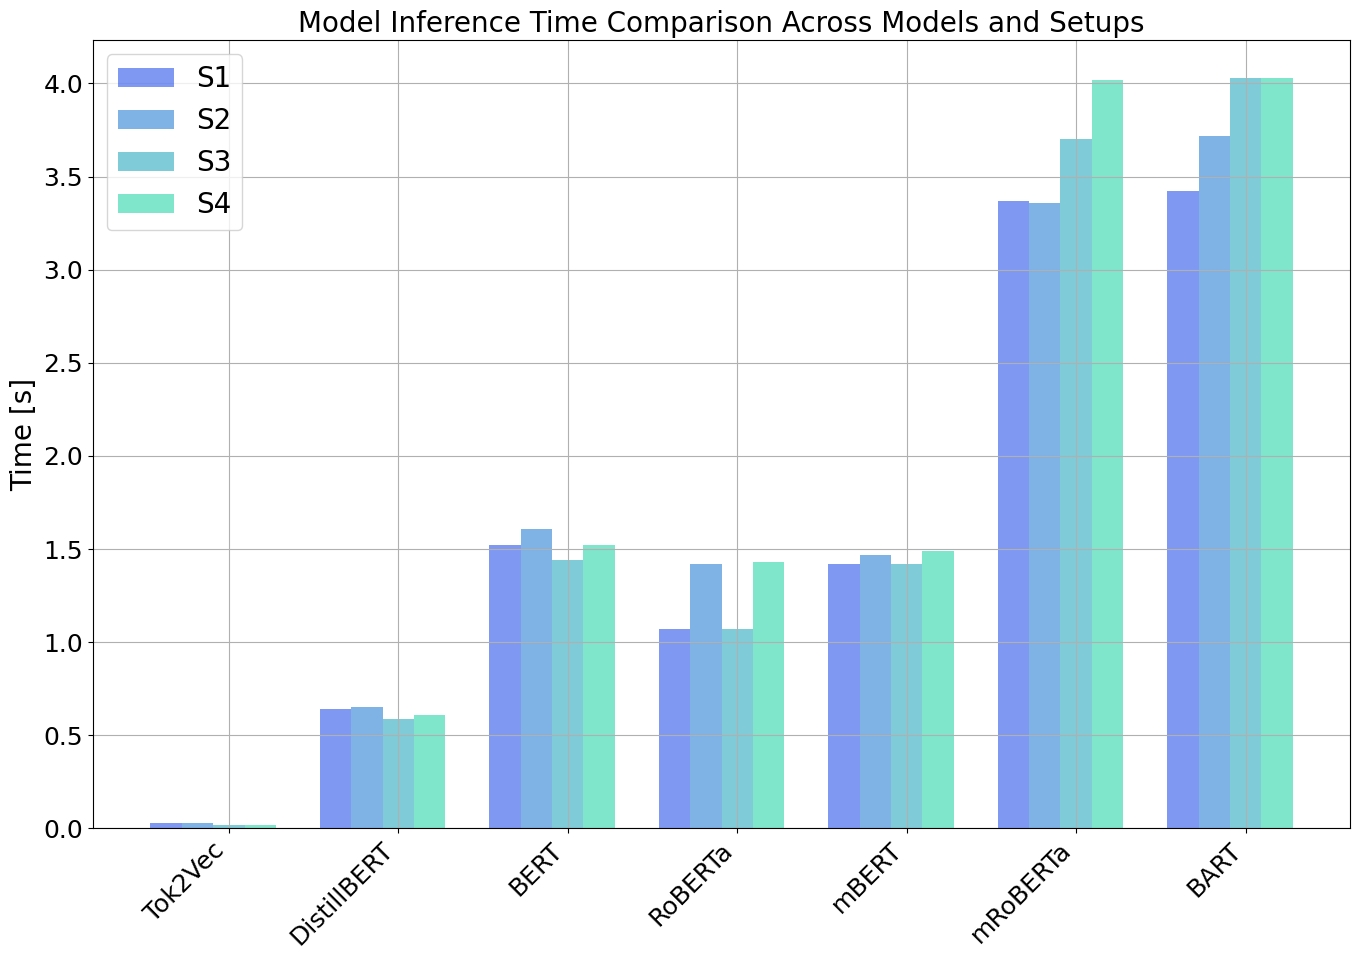

In [29]:
# We'll assume these four setups (matching the time data's 4 values per model):
setup_names = [
    "S1",
    "S2",
    "S3",
    "S4",
]

models = list(time_data.keys())  # or sorted(...) if you want a specific order
n_models = len(models)           # 7
n_setups = len(setup_names)      # 4

# Prepare the x-axis index for each model group
x_indices = np.arange(n_models)

# Set up bar parameters
bar_width = 0.18  # width of each bar
group_gap = 0.25  # extra gap between groups
group_width = n_setups * bar_width  # total width used by 4 bars in one group
step = group_width + group_gap      # distance to the next group center

# Discrete colors from the 'winter' colormap for the 4 setups
cmap = plt.get_cmap('winter')
colors = [cmap(i) for i in np.linspace(0.2, 0.8, n_setups)]
# e.g. colors[0], colors[1], colors[2], colors[3]

fig, ax = plt.subplots(figsize=(14, 10))
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20
})
# Plot each of the 4 setups
for j in range(n_setups):
    # x-positions for bars in the j-th setup across the 7 groups
    x_positions = [i * step + j * bar_width for i in range(n_models)]
    
    # y-values for j-th setup across each model
    y_values = [time_data[model][j] for model in models]
    
    # Draw bars
    ax.bar(
        x_positions, 
        y_values, 
        width=bar_width,
        color=colors[j], 
        edgecolor='none',
        alpha=0.5,
        label=setup_names[j]
    )

# Set up x-ticks at center of each group:
# The center of group i is i*step + (group_width/2)
group_centers = [i * step + (group_width / 2) for i in range(n_models)]

ax.set_xticks(group_centers)
ax.set_xticklabels(models, rotation=45, ha='right')

ax.set_ylabel("Time [s]")
ax.set_title("Model Inference Time Comparison Across Models and Setups")

ax.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig('time_compare.png', dpi=300)
plt.show()

# Sensitivity Analysis